In [1]:
import pandas as pd

**This project analyses Bengaluru housing data using Python, Pandas, NumPy, Matplotlib, and Seaborn. The goal is to clean messy real-estate data, perform exploratory analysis, and answer business questions related to property pricing, locations, and housing trends.**


## Task 1 – Load & First Look


### 1a :
*Load the CSV into a Pandas DataFrame. Print shape, dtypes, and the first 10 rows.*

 Read the data of csv into dataframe variable called df

In [8]:
df=pd.read_csv("data/Bengaluru_House_Data.csv")

In [11]:
print("Shape of dataset :")
print(df.shape)

Shape of dataset :
(13320, 9)


Data Types

In [15]:
print("Data Types:")
print(df.dtypes)

Data Types:
area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object


First 10 rows

In [19]:
print("First 10 Rows:")
print(df.head(10))

First 10 Rows:
              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   
5  Super built-up  Area  Ready To Move                Whitefield      2 BHK   
6  Super built-up  Area         18-May          Old Airport Road      4 BHK   
7  Super built-up  Area  Ready To Move              Rajaji Nagar      4 BHK   
8  Super built-up  Area  Ready To Move              Marathahalli      3 BHK   
9            Plot  Area  Ready To Move              Gandhi Bazar  6 Bedroom   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600

### 1b :
*Count missing values per column. Which column has the most nulls? What percentage of the
dataset does that represent?*

In [23]:
missing_values = df.isnull().sum()
print("Missing Values Per Column:")
print("\n")
print(missing_values)


Missing Values Per Column:


area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64


Find column with maximum null values

In [27]:
max_null_column = missing_values.idxmax()
max_null_count = missing_values.max()
print("\nColumn with most null values:")
print(max_null_column)
print("\nNumber of null values:")
print(max_null_count)



Column with most null values:
society

Number of null values:
5502


Percentage 

In [31]:
percentage = (max_null_count / len(df)) * 100
print(f"\nPercentage of dataset: {percentage:.2f}%")


Percentage of dataset: 41.31%


### 1c :
*Print all unique values in the "size" column (e.g. "2 BHK", "4 Bedroom"). How many distinct
values are there? Do you spot any inconsistencies?*

Print all unique values in the 'size' column

In [37]:
print(df['size'].unique())

['2 BHK' '4 Bedroom' '3 BHK' '4 BHK' '6 Bedroom' '3 Bedroom' '1 BHK'
 '1 RK' '1 Bedroom' '8 Bedroom' '2 Bedroom' '7 Bedroom' '5 BHK' '7 BHK'
 '6 BHK' '5 Bedroom' '11 BHK' '9 BHK' nan '9 Bedroom' '27 BHK'
 '10 Bedroom' '11 Bedroom' '10 BHK' '19 BHK' '16 BHK' '43 Bedroom'
 '14 BHK' '8 BHK' '12 Bedroom' '13 BHK' '18 Bedroom']


Count distinct values

In [41]:
distinct_values = df['size'].nunique()
print("Number of distinct values:")
print(distinct_values)

Number of distinct values:
31


**Observation** - The 'size' column uses different naming formats such as "2 BHK" and "4 Bedroom" to describe property size. Some values are also missing, so the column needs cleaning before analysis.

### 1d :
*Print all unique values in the "area_type" column. 
Write one sentence explaining what each type means (research if needed).*

In [46]:
print(df['area_type'].unique())


['Super built-up  Area' 'Plot  Area' 'Built-up  Area' 'Carpet  Area']



 **Observation**

- *Super built-up Area*: Includes the flat area plus shared spaces like lifts, lobby, and amenities.
- *Built-up Area*: Includes the carpet area plus walls and balconies.
- *Plot Area*: Total land area on which the property is built.
- *Carpet Area*: Actual usable living space inside the house.


## Task 2 – Clean the Data


### 2a :
*The "size" column has values like "2 BHK" and "4 Bedroom". Extract just the NUMBER and create
a new integer column called "bhk". Treat both "BHK" and "Bedroom" as equivalent*

In [52]:
df['bhk'] = df['size'].str.split().str[0]
print(df[['size', 'bhk']].head())

        size bhk
0      2 BHK   2
1  4 Bedroom   4
2      3 BHK   3
3      3 BHK   3
4      2 BHK   2


**Creating the bhk Column**:

The "size" column contains values such as "2 BHK" and "4 Bedroom". To make the data easier to analyze, only the numerical part is extracted and stored in a new column called "bhk". Both "BHK" and "Bedroom" are treated as the same type of property size.

### 2b:
*The "total_sqft" column has ranges like "1200 - 1500". For ranges, use the average. For single
numbers, convert to float. Create a new column "total_sqft_num". Rows that cannot be
converted should be dropped. How many rows did you drop?*

Replace ranges with their average

In [59]:
df['total_sqft_num'] = df['total_sqft']

for i in df.index:

    value = str(df.loc[i, 'total_sqft'])

    if '-' in value:

        a, b = value.split('-')

        df.loc[i, 'total_sqft_num'] = (float(a) + float(b)) / 2

In [60]:
# Convert into numbers
df['total_sqft_num'] = pd.to_numeric(df['total_sqft_num'], errors='coerce')

# Drop invalid rows
before = len(df)

df = df.dropna(subset=['total_sqft_num'])

after = len(df)


Print the rows dropped 

In [64]:
print("Rows dropped:", before - after)

Rows dropped: 46


**Cleaning the total_sqft Column** :


The "total_sqft" column contains both single values and ranges such as "1200 - 1500".  
For range values, the average was calculated so the column could be converted into numeric format. Rows with invalid or non-convertible values were removed to ensure accurate analysis.

### 2c:
*Create a new column "price_per_sqft" = (price × 100000) ÷ total_sqft_num. (Price is in lakhs, so
multiply by 100000 to get rupees.)*

In [69]:
# Create new column for price per square foot
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft_num']

# Show results
print(df[['price', 'total_sqft_num', 'price_per_sqft']].head())

    price  total_sqft_num  price_per_sqft
0   39.07          1056.0     3699.810606
1  120.00          2600.0     4615.384615
2   62.00          1440.0     4305.555556
3   95.00          1521.0     6245.890861
4   51.00          1200.0     4250.000000


**Creating the price_per_sqft Column** :

A new column called "price_per_sqft" was created to measure the cost of property per square foot. Since the price column is given in lakhs, it was multiplied by 100000 to convert the values into rupees before calculation.

### 2d:
*Drop rows where: bhk is null, bath is null, or price is null. Report how many rows remain after each drop.*

In [74]:
# Rows before dropping
print("Rows before cleaning:", len(df))

# Drop rows where bhk is null
df = df.dropna(subset=['bhk'])
print("Rows after dropping bhk nulls:", len(df))

# Drop rows where bath is null
df = df.dropna(subset=['bath'])
print("Rows after dropping bath nulls:", len(df))

# Drop rows where price is null
df = df.dropna(subset=['price'])
print("Rows after dropping price nulls:", len(df))

Rows before cleaning: 13274
Rows after dropping bhk nulls: 13258
Rows after dropping bath nulls: 13201
Rows after dropping price nulls: 13201


**Removing missing values** :

Rows with missing values in the "bhk", "bath", and "price" columns were removed because these fields are important for property analysis. Removing null values helps ensure that calculations and visualizations are based on complete and reliable data.

### 2e:
*Remove obvious outliers: (a) drop rows where price_per_sqft < 1000 or > 100000, (b) drop rows
where bath > bhk + 2. Justify both thresholds in a markdown cell.*


Rows where price_per_sqft < 1000 or > 100000

In [80]:
df = df[(df['price_per_sqft'] >= 1000) & (df['price_per_sqft'] <= 100000)]
print("Remaining rows:", len(df))

Remaining rows: 13185


 Rows where bath > bhk + 2.

In [84]:
df['bhk'] = pd.to_numeric(df['bhk'])
df = df[df['bath'] <= df['bhk'] + 2]
print("Remaining rows:", len(df))


Remaining rows: 13169


**Removing Outliers** :

Rows with extremely low or extremely high price_per_sqft values were removed because they are likely data-entry errors or unrealistic property listings. Properties where the number of bathrooms was much higher than the number of bedrooms were also removed, since such cases are uncommon and may affect the accuracy of the analysis.


## Task 3 – Statistical Analysis with NumPy

In [90]:
import numpy as np

### 3a :
*Using numpy, calculate: mean, median, standard deviation, 25th percentile, and 75th percentile
of price_per_sqft. Print a neat summary table.*

In [94]:
mean = np.mean(df['price_per_sqft'])
median = np.median(df['price_per_sqft'])
std = np.std(df['price_per_sqft'])
q1 = np.percentile(df['price_per_sqft'], 25)
q3 = np.percentile(df['price_per_sqft'], 75)
print("Summary Statistics\n")

print(f"Mean                 : {mean}")
print(f"Median               : {median}")
print(f"Standard Deviation   : {std}")
print(f"25th Percentile      : {q1}")
print(f"75th Percentile      : {q3}")

Summary Statistics

Mean                 : 6675.515914873352
Median               : 5433.829973707274
Standard Deviation   : 4277.218492701132
25th Percentile      : 4268.525896414342
75th Percentile      : 7307.692307692308


### 3b:
*The IQR (Interquartile Range) = Q3 − Q1. Calculate IQR for price_per_sqft. Are there still outliers
outside Q1 − 1.5×IQR and Q3 + 1.5×IQR? How many?*

In [98]:
# Calculate IQR
iqr = q3 - q1

# Lower and upper limits
lower_limit = q1 - (1.5 * iqr)
upper_limit = q3 + (1.5 * iqr)

# Find outliers
outliers = df[
    (df['price_per_sqft'] < lower_limit) |
    (df['price_per_sqft'] > upper_limit)
]

# Print results
print("IQR:", iqr)
print(" ")
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Number of Outliers:", len(outliers))

IQR: 3039.1664112779654
 
Lower Limit: -290.22372050260583
Upper Limit: 11866.441924609255
Number of Outliers: 1254


### 3c:
*Calculate the Pearson correlation coefficient between total_sqft_num and price using
numpy.corrcoef. Interpret the result: is it a strong/weak positive/negative relationship?*

In [102]:
# Calculate correlation matrix
corr_matrix = np.corrcoef(df['total_sqft_num'], df['price'])

# Get Pearson correlation value
r = corr_matrix[0][1]

# Print result
print("Pearson Correlation Coefficient:", r)

Pearson Correlation Coefficient: 0.7087132040074374


The Pearson correlation coefficient is approximately **0.71**, which indicates a **strong positive** relationship between **total square footage and price**. This means that as the size of a property increases, its price also tends to increase.

### 3d:
*For each value of bhk (1, 2, 3, 4, 5), calculate the median price. Which BHK type has the highest
median price per sqft?*

In [107]:
for i in [1, 2, 3, 4, 5]:

    prices = df[df['bhk'] == i]['price']

    median_price = np.median(prices)

    print(f"{i} BHK Median Price: {median_price}")


# Find median price_per_sqft for each bhk
median_pps = []

for i in [1, 2, 3, 4, 5]:

    pps = df[df['bhk'] == i]['price_per_sqft']

    median_pps.append(np.median(pps))


1 BHK Median Price: 34.18
2 BHK Median Price: 53.67
3 BHK Median Price: 88.0
4 BHK Median Price: 202.0
5 BHK Median Price: 175.0


Find bhk with highest median price_per_sqft

In [111]:
highest_bhk = np.argmax(median_pps) + 1
print("\nBHK with highest median price per sqft:", highest_bhk)


BHK with highest median price per sqft: 5


## Task 4 – Exploratory Analysis & Visualisation

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

### 4a:
*Plot a histogram of price_per_sqft. Is the distribution skewed? What does that tell you about
the Bengaluru property market?*

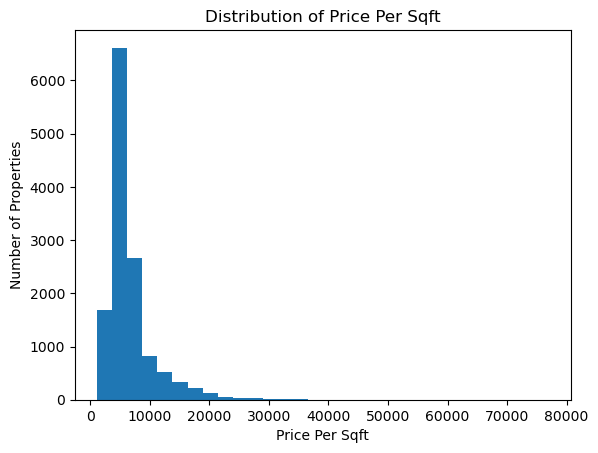

In [118]:
plt.hist(df['price_per_sqft'], bins=30)

plt.title("Distribution of Price Per Sqft")
plt.xlabel("Price Per Sqft")
plt.ylabel("Number of Properties")

plt.show()

The histogram is **positively skewed**, meaning most properties have lower to medium price per square foot while a few properties are extremely expensive. This suggests that the Bengaluru housing market contains a small number of high-end luxury properties that **increase the overall price distribution.**

### 4b:
*Plot a box plot of price grouped by bhk (1 BHK, 2 BHK, 3 BHK, 4 BHK). What pattern do you see?
Are there any surprising outliers in a specific BHK group?*

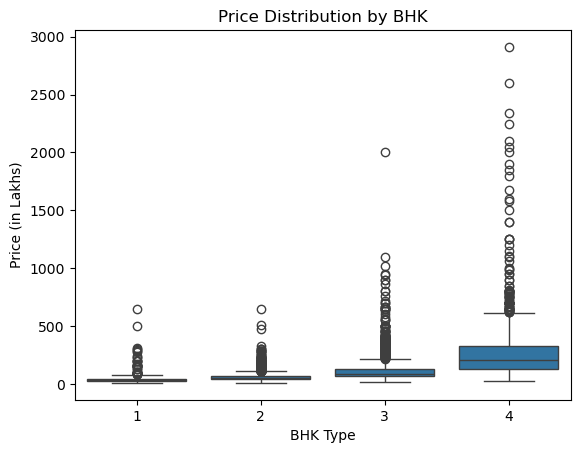

In [122]:
filtered_df = df[df['bhk'].isin([1, 2, 3, 4])]

sns.boxplot(x='bhk', y='price', data=filtered_df)

plt.title("Price Distribution by BHK")
plt.xlabel("BHK Type")
plt.ylabel("Price (in Lakhs)")

plt.show()

The box plot shows that **property prices tend to increase as the number of BHKs increases**. Compared to 1 BHK and 2 BHK homes, 3 BHK and 4 BHK properties have higher prices and greater variation in pricing.
The graph also **shows several outliers**, especially in the 4 BHK category, which likely represent premium or luxury houses.

### 4c:
*Find the top 10 locations by number of listings. Plot a horizontal bar chart. Which location dominates?*

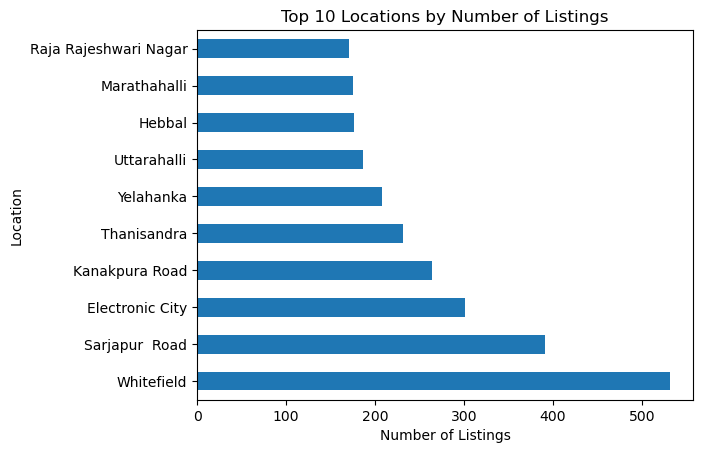

In [126]:
top_locations = df['location'].value_counts().head(10)

top_locations.plot(kind='barh')

plt.title("Top 10 Locations by Number of Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Location")

plt.show()

The bar chart shows the top 10 locations with the highest number of property listings in Bengaluru. **Whitefield** has the highest number of listings, making it the most dominant location in the dataset. 

### 4d:
*Plot a scatter plot of total_sqft_num (x-axis) vs price (y-axis). Colour points by bhk. What
relationship do you see? Are there any listings that look suspicious (very large area, very low
price)?*

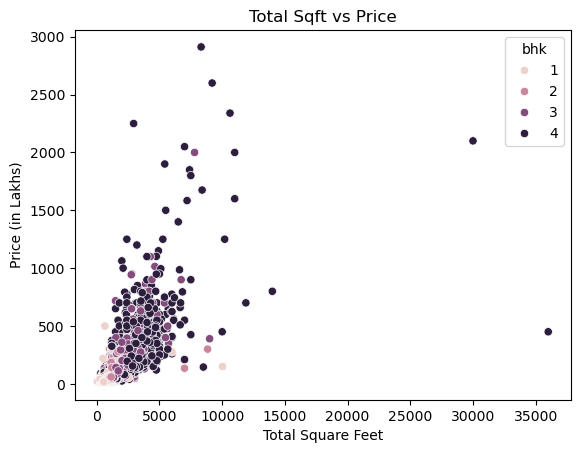

In [132]:
filtered_df = df[df['bhk'].isin([1, 2, 3, 4])]

sns.scatterplot(
    x='total_sqft_num',
    y='price',
    hue='bhk',
    data=filtered_df
)

plt.title("Total Sqft vs Price")
plt.xlabel("Total Square Feet")
plt.ylabel("Price (in Lakhs)")

plt.show()

The scatter plot shows that larger properties generally have higher prices. A few listings with very **large areas  but low prices appear unusual and may be outliers.**

### 4d:
*For the top 5 locations by listing count, calculate the mean price_per_sqft. Plot a bar chart
comparing them. Which location is most expensive per sqft? Which is most affordable?*

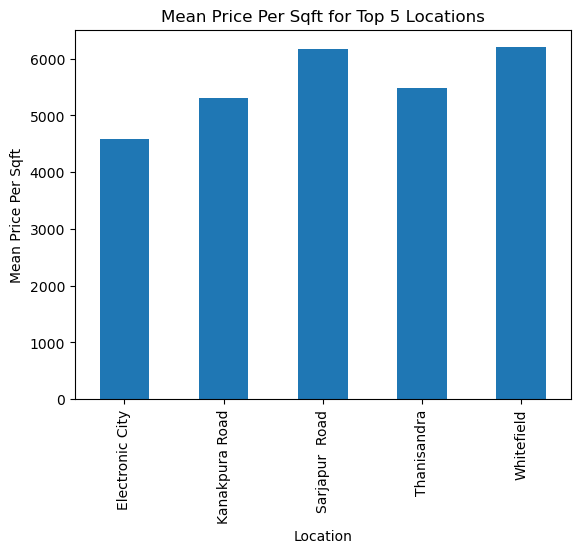

Most Expensive: Whitefield
Most Affordable: Electronic City


In [138]:
top5 = df['location'].value_counts().head(5).index

mean_pps = df[df['location'].isin(top5)].groupby('location')['price_per_sqft'].mean()

mean_pps.plot(kind='bar')

plt.title("Mean Price Per Sqft for Top 5 Locations")
plt.xlabel("Location")
plt.ylabel("Mean Price Per Sqft")

plt.show()

print("Most Expensive:", mean_pps.idxmax())
print("Most Affordable:", mean_pps.idxmin())

The bar chart compares the average price per square foot for the top 5 locations by listing count. **Whitefield has the highest average** price per square foot, making it the most **expensive location**, while **Electronic City is the most affordable** among the top 5 locations. This shows that property prices vary noticeably across different areas of Bengaluru.

## Task 5 – Answer the Business Questions

### 5a :
*Which 5 locations have the highest average price per sqft? (Only include locations with at least
50 listings – otherwise the average is unreliable.)*

In [146]:
location_counts = df['location'].value_counts()

valid_locations = location_counts[location_counts >= 50].index

top_locations = df[df['location'].isin(valid_locations)] \
    .groupby('location')['price_per_sqft'] \
    .mean() \
    .sort_values(ascending=False) \
    .head(5)

print(top_locations)

location
Rajaji Nagar    13906.424605
Malleshwaram    13838.684162
Nagarbhavi      10690.282606
Koramangala     10522.867862
Hebbal           7449.043325
Name: price_per_sqft, dtype: float64


The locations with the highest average price per square foot are **Rajaji Nagar, Malleshwaram, Nagarbhavi, Koramangala, and Hebbal**. Rajaji Nagar had the highest average price per square foot at approximately 13,906, followed closely by Malleshwaram at around 13,839. These locations are likely premium residential areas with high demand and better infrastructure compared to other parts of Bengaluru.

### 5b:
*Does the number of bathrooms significantly affect price? Compare the median price of
properties with 2 baths vs 3 baths vs 4 baths. What is your conclusion?*

In [151]:
bath2 = df[df['bath'] == 2]['price'].median()
bath3 = df[df['bath'] == 3]['price'].median()
bath4 = df[df['bath'] == 4]['price'].median()

print("2 Baths Median Price:", bath2)
print("3 Baths Median Price:", bath3)
print("4 Baths Median Price:", bath4)

2 Baths Median Price: 55.5
3 Baths Median Price: 100.0
4 Baths Median Price: 180.0


The **median price clearly increases with the number of bathrooms**. Properties with **2 bathrooms have a median price of ₹55.5 lakh**, while properties with 3 bathrooms have a median price of ₹100 lakh. Homes with 4 bathrooms are even more expensive, with a median price of ₹180 lakh. This shows that the number of bathrooms has a strong effect on property price and is usually linked to larger and more premium homes.


### 5c:
*What proportion of the original dataset was removed during cleaning? Create a small summary
table: starting rows → rows after each cleaning step → final rows. Calculate total data loss as a
percentage.*

In [156]:
print(df.shape)
original_df = pd.read_csv("data/Bengaluru_House_Data.csv")

print(original_df.shape)

(13169, 12)
(13320, 9)


In [158]:
original_rows = 13320
final_rows = 13169

data_loss = ((original_rows - final_rows) / original_rows) * 100

print(round(data_loss, 2), "%")

1.13 %


The dataset size **decreased** after cleaning because rows with missing values and unrealistic data were removed. Only about **1.13%**  of the original dataset was removed, meaning **most of the data was still usable after preprocessing.**

### 5d:
*BONUS: Is a 2 BHK in Whitefield a better deal than a 2 BHK in Koramangala? Use median
price_per_sqft to make the case. Which area would you recommend to a first-time buyer on a
₹60 lakh budget?*

In [163]:
# Median price_per_sqft for 2 BHK homes

whitefield_price = df[
    (df['location'] == 'Whitefield') &
    (df['bhk'] == 2)
]['price_per_sqft'].median()

koramangala_price = df[
    (df['location'] == 'Koramangala') &
    (df['bhk'] == 2)
]['price_per_sqft'].median()

print("Whitefield Median Price/Sqft:", whitefield_price)
print("Koramangala Median Price/Sqft:", koramangala_price)

Whitefield Median Price/Sqft: 4932.735426008969
Koramangala Median Price/Sqft: 8397.435897435898


The median price per square foot for a 2 BHK in Whitefield is approximately ₹4,933, while in Koramangala it is around ₹8,397. This shows that **Koramangala is significantly more expensive than Whitefield**. For a first-time buyer with a ₹60 lakh budget, **Whitefield** would be the better option because it offers **more affordable homes** and **better value for money.**